# CNN Lab: Binary Image Classification with PyTorch

**Topic:** Introduction to Convolutional Neural Networks  
**Task:** Build a CNN for binary classification (Cats vs Dogs)

In this lab, you will:
- load images from structured folders
- train a CNN on the training set
- monitor validation performance
- evaluate the model on the test set
- analyze errors

# Learning Objectives

By the end of this lab, you should be able to:

- explain why CNNs are well suited for images
- preprocess image data with PyTorch/torchvision
- build and train a CNN for binary classification
- interpret training and validation curves
- evaluate a model on a test set
- inspect prediction errors

# Before You Start

Answer these questions before running the notebook:

1. Why is a CNN more suitable than an MLP for image classification?
2. What is the difference between a convolution layer and a pooling layer?
3. Why do we normalize image pixel values?
4. Why is the output layer composed of a single neuron with a sigmoid activation in binary classification? *(Note: in PyTorch we will keep this neuron as a raw logit and apply the sigmoid implicitly inside the loss function — see Step 5.)*

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


In [4]:
print("Using device:", device)

Using device: cuda


# Step 1 — Import Libraries

We use:

- **NumPy** for numerical arrays
- **Matplotlib** for visualization
- **PyTorch / torchvision** to build and train the CNN
- **`ImageFolder` + `DataLoader`** to load and preprocess images (the torchvision equivalent of Keras's `ImageDataGenerator.flow_from_directory`)

In [5]:
np.random.seed(42)
torch.manual_seed(42)

# Reproducibility

We set random seeds to make the experiment more reproducible.

**Question:**  
Why might the results still vary slightly from one run to another?

# Step 2 — Prepare the Dataset

We propose to use an existing dataset of dogs and cats available on this link:
https://drive.google.com/file/d/1FVomvGZ9dQhuc_DG4qc6yumM-NXJOzVx/view?usp=sharing

The complete dataset is also available on the Kaggle platform:
https://www.kaggle.com/c/dogs-vs-cats-redux-kernels-edition/data

Download the image database from the google drive link and extract it and you can then get the data:

- `data/train/cats`
- `data/train/dogs`
- `data/validation/cats`
- `data/validation/dogs`
- `data/test/cats`
- `data/test/dogs`

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/AIM/TPs/Data_TP/data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [8]:
base_dir = "data"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

print("Train directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Train directory exists: True
Validation directory exists: True
Test directory exists: True


# Quick Check

**Questions:**

1. Why do we separate training and validation data?
2. What could happen if we evaluated the model only on training images?

In [9]:
# Create Datasets and DataLoaders

# We rescale pixel values to the range [0,1] via ToTensor(), and resize every image to 150x150.
# This is the torchvision equivalent of ImageDataGenerator(rescale=1./255).

image_size = (150, 150)
batch_size = 32

basic_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),  # scales pixel values to [0, 1]
])

In [10]:
train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=basic_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)

train_generator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_generator = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_generator = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Class to index mapping:", train_dataset.class_to_idx)

Class to index mapping: {'cats': 0, 'dogs': 1}


# Step 3 — Load the Images

We use `datasets.ImageFolder` + `DataLoader` to:

- read the images directly from folders
- resize them to `150 x 150`
- normalize them using `ToTensor()` (scales to `[0, 1]`)
- assign labels automatically from folder names

**Questions:**

1. Why is normalization useful here?
2. Why do we resize all images to the same size?
3. What labels do you expect for the two classes?

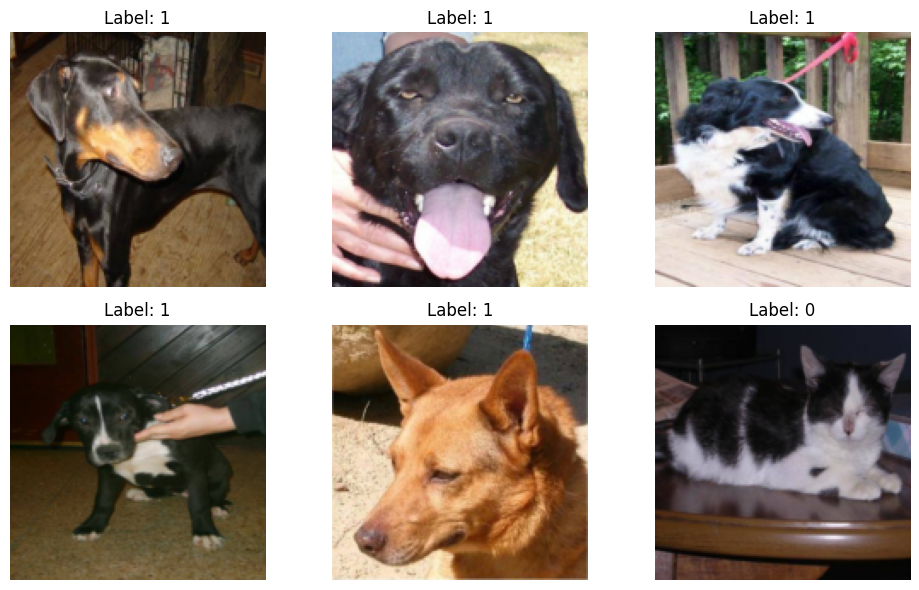

In [11]:
# Visualize a Batch of Training Images

images, labels = next(iter(train_generator))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    # images are (C, H, W) tensors in [0, 1]; permute to (H, W, C) for imshow
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Visual Inspection

**Questions:**

1. Are the images easy for a human to classify?
2. Do all images have the same dimensions after preprocessing?
3. Why is it useful to inspect a batch before training?

# Step 4 — Build a Baseline CNN

We start with a small convolutional model:

- convolution + max pooling blocks
- flatten layer
- dense hidden layer
- a single output neuron producing a raw logit (sigmoid is applied inside the loss function, see Step 5)

This is a basic CNN for binary classification.

In [12]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
        )
        # With 150x150 input, this feature extractor produces 128 channels of 17x17
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # raw logit, no sigmoid here
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BinaryCNN().to(device)
print(model)

BinaryCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=36992, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [13]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,828,481
Trainable parameters: 4,828,481


# Understanding the Architecture

**Questions:**

1. What is the role of a convolution layer?
2. What is the role of max pooling?
3. Why do we flatten the feature maps before the dense layer?
4. Why is the output layer made of one neuron?

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)

# Step 5 — Define the Loss and Optimizer

We choose:

- **`BCEWithLogitsLoss`** for binary classification — this combines a `sigmoid` activation and binary crossentropy in one numerically stable operation, which is why our model outputs a raw logit instead of a probability
- **RMSprop** as optimizer, with the same learning rate (`1e-4`) as the TensorFlow version
- **accuracy**, computed manually, as a first evaluation metric

**Questions:**

1. Why is `BCEWithLogitsLoss` (i.e. `binary_crossentropy` + sigmoid) appropriate here?
2. What does the optimizer do during training?
3. Why is accuracy helpful but not always sufficient?

In [15]:
def evaluate_binary(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device).float().unsqueeze(1)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_binary_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate_binary(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    return history

In [17]:
history = train_binary_model(model, train_generator, validation_generator, criterion, optimizer, device, epochs=10)

Epoch 1/10 - loss: 0.6934 - accuracy: 0.5375 - val_loss: 0.6565 - val_accuracy: 0.6644
Epoch 2/10 - loss: 0.6486 - accuracy: 0.6204 - val_loss: 0.6124 - val_accuracy: 0.6690
Epoch 3/10 - loss: 0.6164 - accuracy: 0.6667 - val_loss: 0.5943 - val_accuracy: 0.7130
Epoch 4/10 - loss: 0.5955 - accuracy: 0.6843 - val_loss: 0.5732 - val_accuracy: 0.7338
Epoch 5/10 - loss: 0.5754 - accuracy: 0.7088 - val_loss: 0.5597 - val_accuracy: 0.6713
Epoch 6/10 - loss: 0.5539 - accuracy: 0.7125 - val_loss: 0.5437 - val_accuracy: 0.7407
Epoch 7/10 - loss: 0.5279 - accuracy: 0.7380 - val_loss: 0.5272 - val_accuracy: 0.7662
Epoch 8/10 - loss: 0.5240 - accuracy: 0.7282 - val_loss: 0.5685 - val_accuracy: 0.7384
Epoch 9/10 - loss: 0.4967 - accuracy: 0.7579 - val_loss: 0.5009 - val_accuracy: 0.7639
Epoch 10/10 - loss: 0.4803 - accuracy: 0.7796 - val_loss: 0.5003 - val_accuracy: 0.7685


# Step 6 — Train the CNN

PyTorch has no built-in `.fit()`, so the explicit training loop above plays the same role: for each epoch, it iterates over mini-batches, computes the loss, backpropagates, and updates the weights.

**Questions before analyzing the results:**

1. What does one epoch mean?
2. Why do we monitor validation performance during training?
3. What would a very large gap between training and validation accuracy suggest?

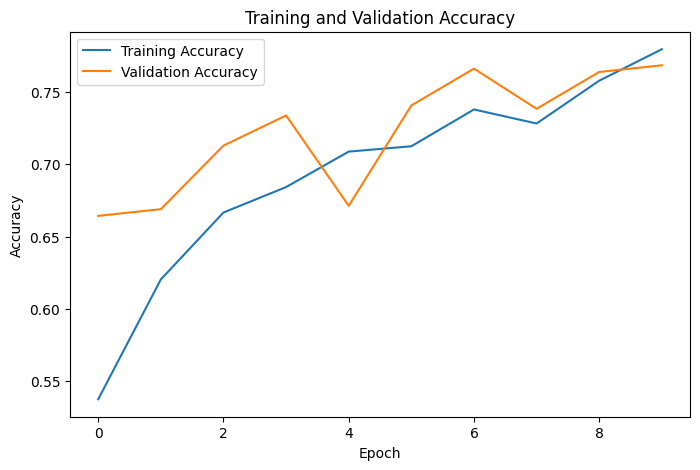

In [18]:
# Plot Training and Validation Accuracy

acc = history["accuracy"]
val_acc = history["val_accuracy"]

plt.figure(figsize=(8, 5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

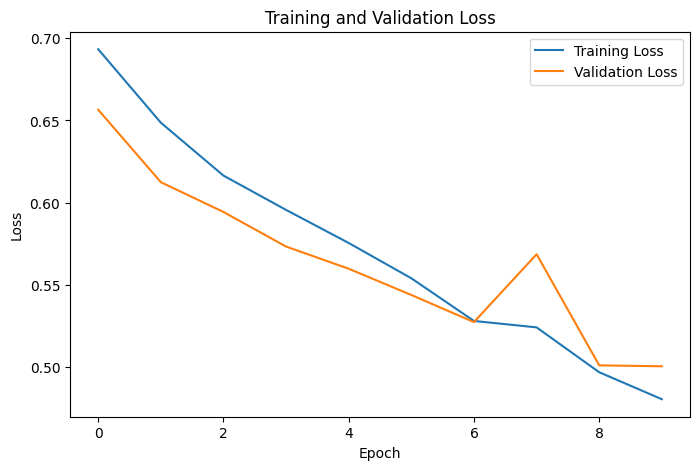

In [19]:
# Plot Training and Validation Loss

loss = history["loss"]
val_loss = history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [20]:
# Evaluation on the Test Set

test_loss, test_acc = evaluate_binary(model, test_generator, criterion, device)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.5539114044772254
Test Accuracy: 0.7256944444444444


# Step 7 — Interpret the Learning Curves

**Short questions:**

1. Does the model improve over the epochs?
2. Is there evidence of overfitting?
3. Around which epoch does validation performance stop improving?
4. Are training and validation curves close or far apart?

In [21]:
# Generate Predictions on the Test Set

model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in test_generator:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
        all_probs.append(probs)
        all_true.append(yb.numpy())

y_pred_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_true)
y_pred = (y_pred_probs > 0.5).astype(int)

class_labels = [name for name, idx in sorted(test_dataset.class_to_idx.items(), key=lambda x: x[1])]

print("Number of test samples:", len(y_true))
print("First 10 predicted labels:", y_pred[:10])

Number of test samples: 288
First 10 predicted labels: [0 0 0 1 0 1 0 1 0 0]


# Step 8 — Make Predictions

The model outputs a raw logit; we apply `torch.sigmoid` manually to get a probability between 0 and 1.

- close to 0: one class
- close to 1: the other class

We convert probabilities into class labels using a threshold of `0.5`.

**Questions:**

1. What does a probability of `0.92` mean?
2. Why do we use a threshold?
3. Could a different threshold change the results?

# Short Improvement Ideas

Try **one** of the following changes:

- add `nn.Dropout(0.3)` after the dense layer *(already present in the baseline above — try increasing it)*
- replace `RMSprop` with `Adam`
- increase or decrease the number of filters
- use data augmentation in the training transform

Then compare the new curves with the baseline.

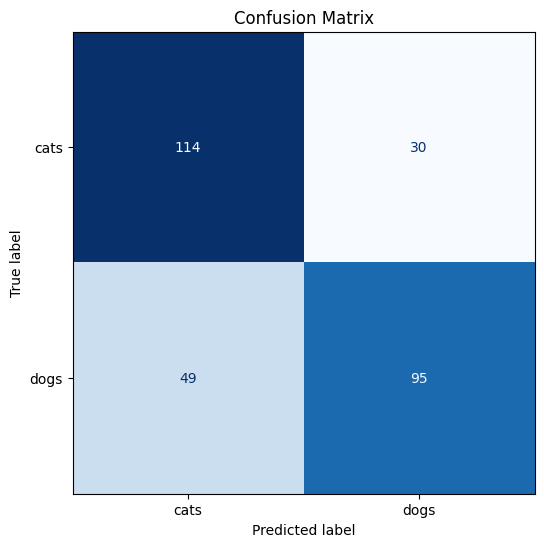

In [22]:
#Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Classification Report

print(classification_report(y_true, y_pred, target_names=class_labels))

              precision    recall  f1-score   support

        cats       0.70      0.79      0.74       144
        dogs       0.76      0.66      0.71       144

    accuracy                           0.73       288
   macro avg       0.73      0.73      0.72       288
weighted avg       0.73      0.73      0.72       288



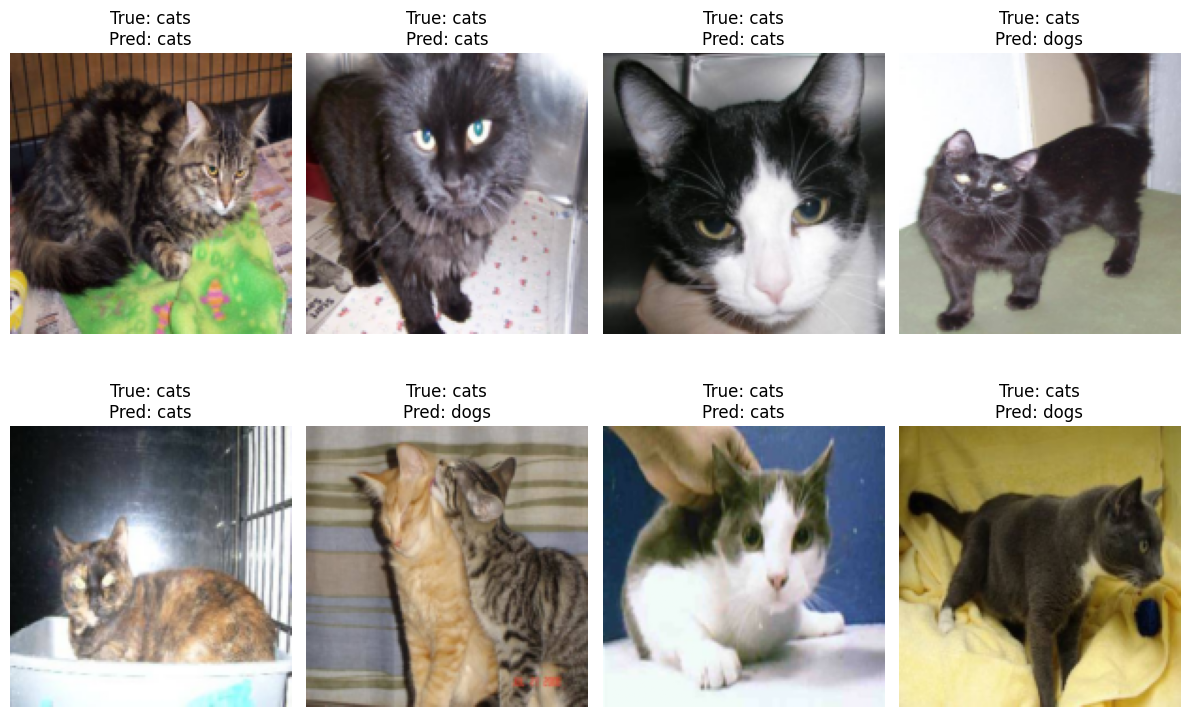

In [24]:
# Show Some Test Predictions

sample_images, sample_labels = next(iter(test_generator))
with torch.no_grad():
    sample_probs = torch.sigmoid(model(sample_images.to(device))).cpu().numpy().reshape(-1)
sample_preds = (sample_probs > 0.5).astype(int)

plt.figure(figsize=(12, 8))
for i in range(min(8, len(sample_images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i].permute(1, 2, 0).numpy())
    true_label = class_labels[int(sample_labels[i])]
    pred_label = class_labels[int(sample_preds[i])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

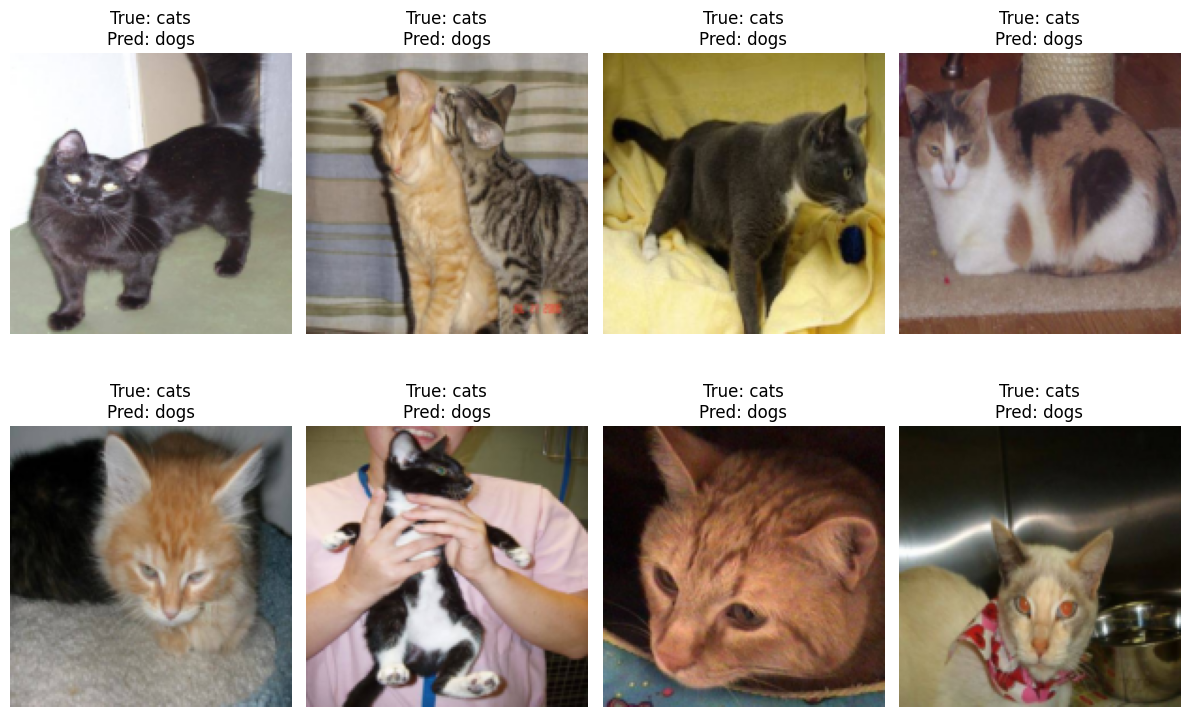

In [25]:
# Show Misclassified Test Images

all_test_images = []
for xb, yb in test_generator:
    all_test_images.append(xb.numpy())
all_test_images = np.vstack(all_test_images)

misclassified_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified_idx[:8]):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.transpose(all_test_images[idx], (1, 2, 0)))
    true_label = class_labels[int(y_true[idx])]
    pred_label = class_labels[int(y_pred[idx])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Short Questions

1. Why is a CNN more suitable than an MLP for image classification?
2. What is the role of convolution layers?
3. What is the role of max pooling?
4. Based on the curves, does the model overfit?
5. Which class seems harder to classify?
6. What kinds of mistakes does the model make?
7. What would you try next to improve performance?

# Small optional improvement

If you want, you can replace the training transform with augmentation:

In [26]:
train_transform_aug = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(image_size, scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

while keeping validation and test transforms with only:

In [27]:
transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

Compose(
    Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

# Optional Improvement

Try one of the following:

- add more data augmentation
- change the number of filters
- add another convolution block
- change the dropout rate
- train for more epochs with early stopping

Then compare the new test results with the baseline model.

# Final Questions (Short Version)

Answer briefly:

1. Why is a CNN more appropriate than an MLP for images?
2. What is the difference between convolution and pooling?
3. Based on the curves, does your model overfit or generalize reasonably well?
4. What is one limitation of this baseline CNN?
5. What is one improvement you would test next?

# Mini Task

Modify the baseline model with **one improvement** and report:

1. What did you change?
2. Why did you choose this change?
3. Did validation accuracy improve?
4. Did overfitting increase or decrease?